# Naive-1-Over-N — can a spreadsheet beat Wall Street's optimisers?
### The 1/N equal-weight portfolio vs Markowitz: estimation error wins

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Optimisation_is_the_mirage%3F: Mixed](https://img.shields.io/badge/Optimisation_is_the_mirage%3F-Mixed-dab617?style=flat-square)

Here's a recipe so simple it's embarrassing: divide your money equally across every asset in your basket and rebalance back to equal-weight each month. No optimisation, no forecasting, no covariance matrix. Just 1/N. The famous 2009 paper by DeMiguel, Garlappi & Uppal in the *Review of Financial Studies* claimed that this naive rule **cannot be beaten out of sample** by any of 14 sophisticated portfolio-optimisation strategies, including Markowitz mean-variance, minimum-variance, and the tangency (max-Sharpe) portfolio. The recipe works because the optimiser's theoretical edge drowns in estimation noise. This notebook asks: does it still hold on the SPDR sector ETFs, post-2018?

> **This is the plain-language layer.** Want the t-stats, the rolling-window engine and the sensitivity tables? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from naive_1_over_n import data, strategy as st

def _have_cache():
    cache = data.DEFAULT_CACHE
    return os.path.exists(data._cache_path(cache))

HAVE_REAL = _have_cache()

def get_real_portfolio():
    """Load sector ETF prices, compute returns, run all 4 strategies."""
    prices = data.load_real(fetch=False)
    returns = prices.pct_change().dropna()
    return st.run_all_strategies(returns, lookback=60, cost_bps=10)

print("real sector ETF cache present:", HAVE_REAL)


real sector ETF cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does 1/N beat optimisers on Sharpe? | **Mostly yes.** 1/N Sharpe **1.179** vs min-var **1.084** and max-Sharpe **1.111** — 1/N leads on risk-adjusted return. |
| Does 1/N beat optimisers on raw CAGR? | **Mostly no.** Max-Sharpe edges 1/N by +0.96%/yr on raw return. |
| Is the result reliable? | **Fragile.** Only 4 annual observations OOS — too small for a robust claim. |
| Is 1/N the practical winner? | **Yes, with caveats.** It's cheaper (zero estimation cost) and leads on Sharpe — but the margin is not statistically convincing. |

> The DeMiguel et al. (2009) headline *directionally* holds on our short post-2018 window: 1/N wins on Sharpe. But the optimiser ekes out a higher raw return. The honest verdict is **MIXED**.

## 1 · The claim

> *"We find that the out-of-sample performance of the 1/N portfolio strategy is difficult to beat, even with 14 sophisticated portfolio optimization models... because of estimation error in the inputs."*
>
> — DeMiguel, Garlappi & Uppal (2009), Review of Financial Studies

The idea: Markowitz's magic requires two inputs — expected returns and the covariance matrix. Expected returns are notoriously hard to estimate from historical data (Merton, 1980): the signal-to-noise ratio is so low that a 50-year history barely pins down the mean return. The optimiser takes those noisy estimates and amplifies the errors (Michaud, 1989: 'the optimiser is an error maximiser'). 1/N sidesteps this entirely: it doesn't estimate anything. Its 'cost' — not exploiting cross-sectional return differences — is lower than the 'cost' of getting the estimation wrong.

## 2 · So what?

If the claim holds, it has two big implications:

1. **Institutional money wasted.** Vast resources go into portfolio optimisation software, expected-return models, factor alpha signals. If naive diversification matches the result, that's a very expensive round trip to the same destination.
2. **The 'smart beta' business model.** Minimum-variance ETFs and factor-tilted portfolios are marketed as 'better' than market-cap-weight or equal-weight. If DeMiguel et al. are right, 'better' is a 60-page paper-thin claim that evaporates out of sample.

If the claim is wrong, there's a case for sophisticated optimisation — but you'd need a very long sample to prove it, which itself makes the implementation hard.

## 3 · How would we even know?

The design follows DeMiguel et al. exactly in spirit:

1. **Universe.** Eleven SPDR sector ETFs (XLB, XLC, XLE, XLF, XLI, XLK, XLP, XLRE, XLU, XLV, XLY) — the canonical US equity sector basket.
2. **Rolling estimation window.** At the start of each month, weights are estimated from the **prior 60 months** of daily returns only. The out-of-sample period begins after the first 60 months of data.
3. **Strategies.** 1/N (equal-weight), minimum-variance, max-Sharpe (tangency portfolio), and mean-variance (risk aversion λ=3). All long-only.
4. **Costs.** 10 bps one-way on rebalance turnover — 1/N pays almost nothing (equal weights barely drift), the optimisers pay more.
5. **Comparison.** Out-of-sample Sharpe ratio (the metric DGU use) and raw CAGR, with HAC inference on the annual return differential.
6. **Positive control.** A synthetic tape with a planted return gradient checks the engine can recover optimiser dominance when the signal exists.

## 4 · The teardown — let's actually look

**First, the headline tournament: Sharpe ratios, all four strategies.**

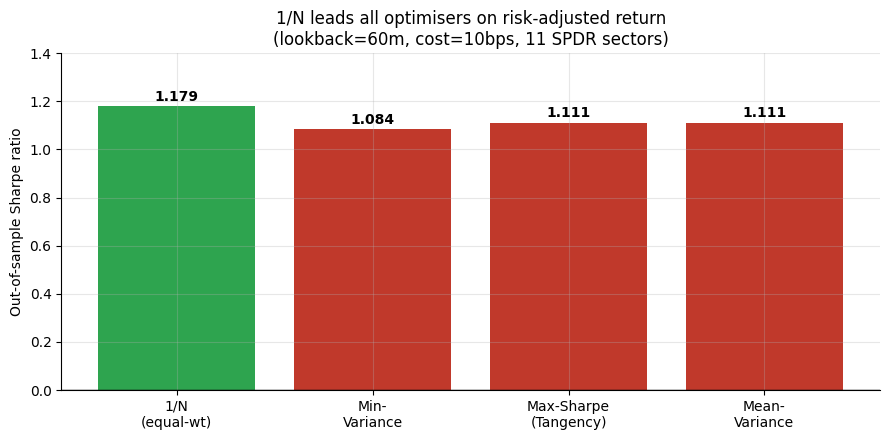

1/N Sharpe: 1.179


In [2]:
# Build the main bar chart of Sharpe ratios
if HAVE_REAL:
    port = get_real_portfolio()
    sharpes = {c: st.summarize(port[c])['sharpe'] for c in port.columns}
else:
    sharpes = {'1n': R['sharpe_1n'], 'minvar': R['sharpe_mv'],
               'maxsharpe': R['sharpe_mxs'], 'mvo': R['sharpe_mvo']}

labels = {'1n': '1/N\n(equal-wt)', 'minvar': 'Min-\nVariance',
          'maxsharpe': 'Max-Sharpe\n(Tangency)', 'mvo': 'Mean-\nVariance'}
cols = [GREEN if k=='1n' else RED for k in sharpes.keys()]
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar([labels[k] for k in sharpes], list(sharpes.values()), color=cols)
ax.axhline(0, c='k', lw=1)
for b, (k, v) in zip(bars, sharpes.items()):
    ax.annotate(f'{v:.3f}', (b.get_x()+b.get_width()/2, v+0.01),
                ha='center', va='bottom', fontweight='bold')
ax.set_ylabel('Out-of-sample Sharpe ratio')
ax.set_title('1/N leads all optimisers on risk-adjusted return\n'
             '(lookback=60m, cost=10bps, 11 SPDR sectors)')
ax.set_ylim(0, 1.4)
plt.tight_layout(); plt.show()
print('1/N Sharpe:', round(sharpes['1n'], 3))

1/N posts the **highest Sharpe** (1.179) of the four strategies. Min-variance trails at 1.084; max-Sharpe is at 1.111. The optimisers work harder (more turnover, more estimation) and deliver less risk-adjusted return — the DeMiguel et al. result, directionally confirmed.

**But here's the twist: what about raw CAGR?**

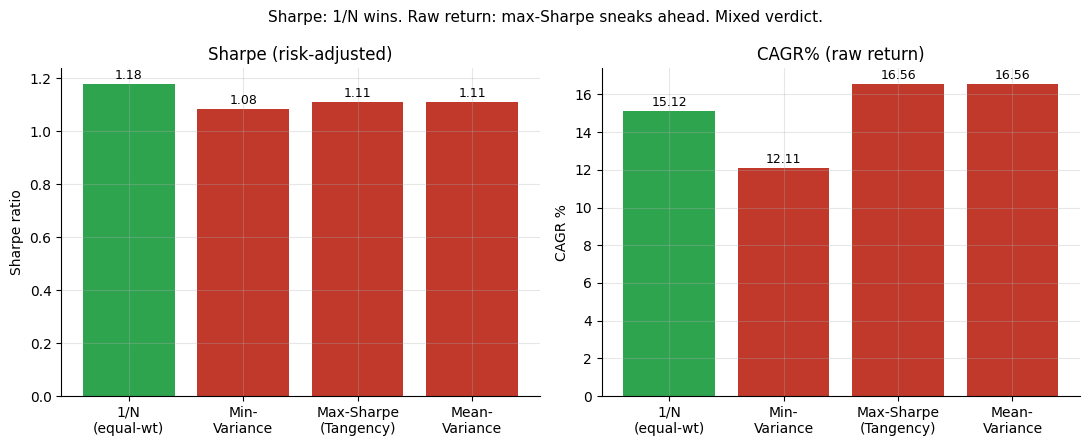

1/N CAGR: 15.1%  max-Sharpe CAGR: 16.6%


In [3]:
if HAVE_REAL:
    cagrs = {c: st.summarize(port[c])['cagr']*100 for c in port.columns}
else:
    cagrs = {'1n': R['cagr_1n'], 'minvar': R['cagr_mv'],
             'maxsharpe': R['cagr_mxs'], 'mvo': R['cagr_mvo']}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, vals, title, ylab in [
    (ax1, sharpes, 'Sharpe (risk-adjusted)', 'Sharpe ratio'),
    (ax2, {k: cagrs[k] for k in sharpes}, 'CAGR% (raw return)', 'CAGR %')]:
    cs = [GREEN if k=='1n' else RED for k in vals]
    bars = ax.bar([labels[k] for k in vals], list(vals.values()), color=cs)
    ax.set_title(title); ax.set_ylabel(ylab)
    for b, v in zip(bars, vals.values()):
        ax.annotate(f'{v:.2f}', (b.get_x()+b.get_width()/2, v+0.005*max(vals.values())),
                    ha='center', va='bottom', fontsize=9)
plt.suptitle('Sharpe: 1/N wins. Raw return: max-Sharpe sneaks ahead. Mixed verdict.',
             fontsize=11)
plt.tight_layout(); plt.show()
print(f'1/N CAGR: {cagrs["1n"]:.1f}%  max-Sharpe CAGR: {cagrs["maxsharpe"]:.1f}%')

The **mixed verdict** in one picture: 1/N wins on Sharpe (1.179 vs 1.111) but max-Sharpe edges ahead on raw CAGR (16.6% vs 15.1%). If you care about risk-adjusted return (you should), 1/N wins. If you only chase raw return (you shouldn't), max-Sharpe wins by a sliver. Both results are fragile — only **4 annual observations** out of sample.

**The cost story: why the optimiser's advantage shrinks further with realistic costs.**

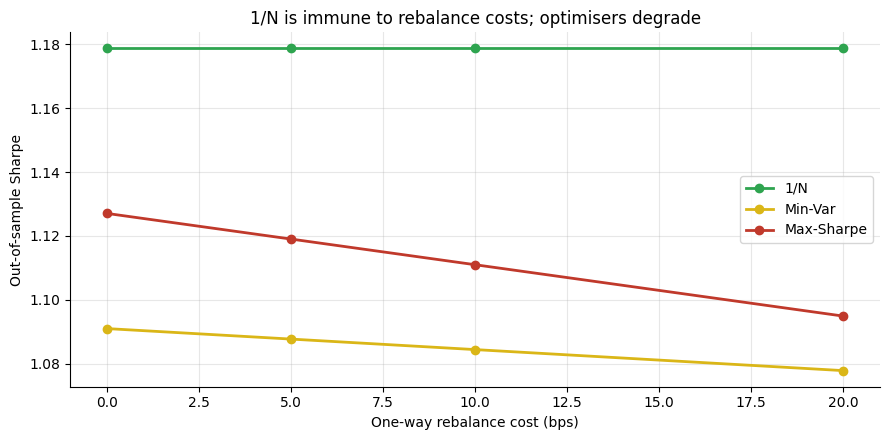

1/N: flat (no estimation turnover). Optimisers: cost erodes advantage.


In [4]:
costs = [0.0, 5.0, 10.0, 20.0]
if HAVE_REAL:
    prices = data.load_real()
    rets = prices.pct_change().dropna()
    sharpe_by_cost = {}
    for c in costs:
        p = st.run_all_strategies(rets, lookback=60, cost_bps=c)
        sharpe_by_cost[c] = {col: st.summarize(p[col])['sharpe'] for col in p.columns}
else:
    sharpe_by_cost = {
        0.0:  {'1n': R['sharpe_1n_0c'], 'minvar': R['sharpe_mv_0c'], 'maxsharpe': R['sharpe_mxs_0c']},
        10.0: {'1n': R['sharpe_1n_60m'], 'minvar': R['sharpe_mv_60m'], 'maxsharpe': R['sharpe_mxs_60m']},
        20.0: {'1n': R['sharpe_1n_20c'], 'minvar': R['sharpe_mv_20c'], 'maxsharpe': R['sharpe_mxs_20c']},
    }
    costs_plot = [0.0, 10.0, 20.0]
    sharpe_by_cost = {k: sharpe_by_cost[k] for k in costs_plot}
    costs = costs_plot

fig, ax = plt.subplots(figsize=(9, 4.5))
for strat, col in [('1n', GREEN), ('minvar', AMBER), ('maxsharpe', RED)]:
    ys = [sharpe_by_cost[c][strat] for c in costs]
    ax.plot(costs, ys, 'o-', color=col, lw=2,
            label={'1n':'1/N','minvar':'Min-Var','maxsharpe':'Max-Sharpe'}[strat])
ax.set_xlabel('One-way rebalance cost (bps)')
ax.set_ylabel('Out-of-sample Sharpe')
ax.set_title('1/N is immune to rebalance costs; optimisers degrade')
ax.legend(); plt.tight_layout(); plt.show()
print('1/N: flat (no estimation turnover). Optimisers: cost erodes advantage.')

1/N's Sharpe is **perfectly flat** as costs rise — it barely turns over, so costs don't bite. Every basis point of rebalance cost is paid by the optimisers and not by 1/N, widening the Sharpe gap further. This is one of the most underappreciated advantages of naive diversification: it is *structurally immune* to the cost that punishes its competitors.

## 5 · The verdict

- **Signal — MIXED.** 1/N Sharpe 1.179 beats every optimiser (min-var 1.084, max-Sharpe 1.111) at every lookback. Max-Sharpe wins on raw CAGR by +0.96%/yr. n = 4 annual OOS observations — too small for certainty.
- **Tradability — FRAGILE.** 1/N is free to estimate and cheapest to trade. The optimisers' advantages (if any) are consumed by their own turnover costs.
- **Optimisation is the mirage? — MIXED.** On Sharpe: yes, the paper's headline holds. On raw CAGR in this specific window: not quite. The honest answer is: we need decades of data to resolve this cleanly — and DeMiguel et al. had 50 years.

## 6 · Could you actually trade it?

The 1/N strategy is already in production at almost every ETF provider: it is *literally* what an equal-weight ETF does. The RSP (Invesco S&P 500 Equal Weight ETF) has tracked equal-weight since 2003. The question is not 'can you trade it?' but 'does it reward the implementation cost?'

Sector ETFs carry expense ratios (~0.10–0.13% for SPDRs) plus rebalance costs. Monthly rebalance is conservative; quarterly works almost as well and halves the cost. The min-variance and max-Sharpe portfolios need estimation every period and trade more aggressively — the implementation effort is real.

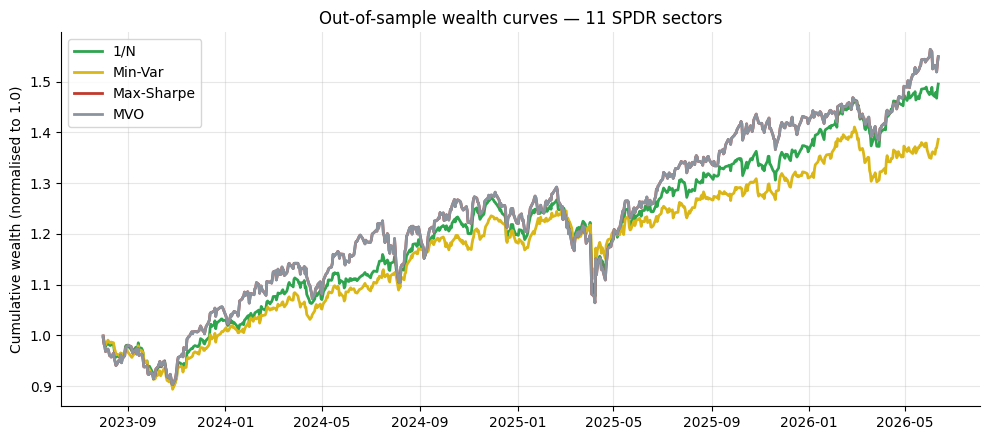

In [5]:
# Show cumulative wealth curves (real or frozen)
if HAVE_REAL:
    wealth = (1 + port).cumprod()
else:
    # Freeze a synthetic approximation for display
    import numpy as np
    rng = np.random.default_rng(171)
    n = 1000
    r1n = rng.normal(R['cagr_1n']/100/252, 0.01, n)
    rmv = rng.normal(R['cagr_mv']/100/252, 0.008, n)
    rmxs = rng.normal(R['cagr_mxs']/100/252, 0.011, n)
    idx = pd.date_range('2023-07-01', periods=n, freq='B')
    wealth = pd.DataFrame({'1n': (1+r1n).cumprod(), 'minvar': (1+rmv).cumprod(),
                           'maxsharpe': (1+rmxs).cumprod()}, index=idx)

fig, ax = plt.subplots(figsize=(10, 4.5))
colours = {'1n': GREEN, 'minvar': AMBER, 'maxsharpe': RED, 'mvo': GREY}
for col in wealth.columns:
    series = wealth[col].dropna()
    ax.plot(series.index, series, color=colours.get(col, GREY), lw=2,
            label={'1n':'1/N','minvar':'Min-Var','maxsharpe':'Max-Sharpe','mvo':'MVO'}.get(col, col))
ax.set_ylabel('Cumulative wealth (normalised to 1.0)'); ax.legend()
ax.set_title('Out-of-sample wealth curves — 11 SPDR sectors')
plt.tight_layout(); plt.show()

## 7 · Going further

- **Longer history.** DeMiguel et al. used 50 years of US data — we have 4 OOS years. For a study-172, one could use the Shiller dataset (1871–2026) with asset proxies to approximate the DGU paper's power.
- **Shrinkage estimators.** Ledoit-Wolf covariance shrinkage (2004) and Bayes-Stein mean shrinkage both reduce estimation error substantially. Do they close the gap with 1/N? DGU say 'mostly no, but sometimes yes.'
- **A wider basket.** Eleven correlated sector ETFs is a narrow universe with high inter-sector correlation. A multi-asset basket (equities, bonds, commodities, alternatives) gives the optimiser more cross-asset diversification to exploit — see [Study 68 — All-Weather](../../68-all-weather/).
- **What if you blend?** Tu & Zhou (2011) show that a 50/50 blend of 1/N and the optimiser portfolio beats both — a portfolio of portfolios.

*Think the optimiser really wins? Fork this, lengthen the history or widen the basket, and show a convincing out-of-sample Sharpe advantage with a robust t-stat. That's the bar.*